# Travel Reimbursement Approval Agent
**AI Developer Candidate Assignment — GenAI / Agentic AI prototype**

A working agent that ingests employee travel reimbursement claims, grounds its reasoning in a
policy knowledge base (rules `POL-*`), calls purpose-built **tools** (policy lookup, receipt
checker, per-diem limit checker, airfare-class checker, timeliness checker, approval-threshold
checker, output validator), and returns a **structured decision** per claim:
`APPROVE`, `PARTIAL_APPROVE`, `REJECT`, or `MANUAL_REVIEW`.

The notebook runs **top-to-bottom with no manual steps**:
- **With an LLM key** (`ANTHROPIC_API_KEY`) → a real agentic tool-use loop: the LLM decides which
  tools to call, combines results, and emits the final structured decision (validated + repaired).
- **Without a key** → a deterministic rule-engine fallback runs the *same tools in the same
  workflow*, so the demo is always reproducible and the outputs are auditable.


## README

### What this is
A lightweight agentic prototype that evaluates 5 provided sample claims (Appendix B) against the
travel reimbursement policy (Appendix A) and emits one structured JSON result per claim.

### Setup
```bash
pip install anthropic pandas matplotlib ipywidgets   # ipywidgets optional (interactive UI)
```
Python ≥ 3.10. No other services required.

### Environment variables (optional)
| Variable | Purpose |
|---|---|
| `ANTHROPIC_API_KEY` | Enables the LLM-driven agent loop (model: `claude-sonnet-4-6`). |
| `AGENT_MODE` | `llm` (default if key present), `deterministic` to force the fallback. |

If no key is set the notebook automatically uses the deterministic engine — **it still runs
end-to-end** and produces identical tool traces and decisions.

### How to run
`Kernel → Restart & Run All`. The final code cell prints the required JSON array
(one object per claim with exactly: `claim_id, decision, approved_amount, deducted_amount,
missing_docs, policy_refs, confidence, explanation, tools_used`).

### Key design choices
1. **Tools are deterministic; the LLM orchestrates.** All money math (caps, deductions,
   thresholds) lives in plain Python tools. The LLM decides *when* to call them and how to
   synthesize findings — never invents numbers. This keeps decisions auditable and reliable.
2. **Manual Review is a first-class outcome.** Missing receipts, non-economy airfare, late
   submission, and totals > $2,000 are never force-decided (POL-RCT-02, POL-AIR-01,
   POL-TIME-01, POL-APR-03).
3. **Schema-validated output with repair.** Every result passes `validate_output`; an invalid
   LLM result is repaired by falling back to the deterministic engine for that claim.
4. **Graceful degradation.** LLM → deterministic fallback means zero-dependency review.


## 1. Setup & configuration

In [12]:
import json, os, textwrap
from datetime import date
import pandas as pd

pd.set_option("display.width", 160)

# ---- agent mode detection -------------------------------------------------
ANTHROPIC_KEY = os.environ.get("ANTHROPIC_API_KEY", "").strip()
MODE = os.environ.get("AGENT_MODE", "").strip().lower()
try:
    import anthropic  # noqa: F401
    _sdk_ok = True
except ImportError:
    _sdk_ok = False

if MODE not in ("llm", "deterministic"):
    MODE = "llm" if (ANTHROPIC_KEY and _sdk_ok) else "deterministic"
if MODE == "llm" and not (ANTHROPIC_KEY and _sdk_ok):
    MODE = "deterministic"

MODEL = "claude-sonnet-4-6"
print(f"Agent mode: {MODE.upper()}"
      + ("" if MODE == "llm" else "  (set ANTHROPIC_API_KEY to enable the LLM tool-use loop)"))

Agent mode: DETERMINISTIC  (set ANTHROPIC_API_KEY to enable the LLM tool-use loop)


## 2. Policy knowledge base & retrieval (context grounding)

The full Appendix A policy is stored as structured rules, each with a stable `POL-*` id.
`policy_lookup` is a lightweight keyword-scored retriever the agent uses to ground every
decision in actual policy text before deciding.

In [13]:
POLICY_RULES = [
    {"id": "POL-CAT-01", "title": "Eligible categories",
     "text": "Reimbursable when incurred for a documented business purpose: airfare (economy only, see POL-AIR-01), lodging, meals (per-diem POL-PD-01), ground transport, conference/registration fees.",
     "keywords": ["eligible", "airfare", "lodging", "meals", "ground", "transport", "conference", "category"]},
    {"id": "POL-CAT-02", "title": "Ineligible items",
     "text": "Never reimbursable, deducted in full: alcohol, minibar, spa, gym, personal entertainment, in-room movies, personal shopping, gifts, traffic fines, penalties, late fees, any personal expense.",
     "keywords": ["ineligible", "alcohol", "minibar", "spa", "gym", "entertainment", "movies", "shopping", "gifts", "fines", "personal"]},
    {"id": "POL-PD-01", "title": "Meals per-diem",
     "text": "Meals maximum $75 per day. Amounts above the daily cap are deducted; the rest is reimbursed.",
     "keywords": ["meals", "per-diem", "per diem", "daily", "cap", "75"]},
    {"id": "POL-PD-02", "title": "Lodging cap",
     "text": "Lodging maximum $200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed.",
     "keywords": ["lodging", "hotel", "night", "cap", "200"]},
    {"id": "POL-PD-03", "title": "Ground transport cap",
     "text": "Ground transport maximum $50 per day. Amounts above the cap are deducted.",
     "keywords": ["ground", "transport", "taxi", "rideshare", "train", "rental", "parking", "50"]},
    {"id": "POL-AIR-01", "title": "Airfare class",
     "text": "Only economy class airfare is reimbursable. Business/first-class fares are a policy exception and must be routed to Manual Review (not auto-deducted, because a pre-approval may exist).",
     "keywords": ["airfare", "economy", "business class", "first class", "class", "flight"]},
    {"id": "POL-RCT-01", "title": "Receipt required above $25",
     "text": "Any single line item greater than $25 requires an attached, itemized receipt. Airfare and lodging always require a receipt regardless of amount.",
     "keywords": ["receipt", "25", "itemized", "attached", "required"]},
    {"id": "POL-RCT-02", "title": "Missing receipt handling",
     "text": "If a receipt is missing for an item that requires one, the item is not silently rejected; the claim is routed to Manual Review so the reviewer can request the receipt.",
     "keywords": ["receipt", "missing", "manual review"]},
    {"id": "POL-APR-01", "title": "Auto-approve tier",
     "text": "Total <= $500: may be auto-approved by the agent if fully compliant.",
     "keywords": ["approval", "threshold", "auto", "500", "tier"]},
    {"id": "POL-APR-02", "title": "Manager tier",
     "text": "Total > $500 and <= $2,000: eligible for approval, treated as approvable when fully compliant.",
     "keywords": ["approval", "threshold", "manager", "2000", "tier"]},
    {"id": "POL-APR-03", "title": "Director / Manual-Review tier",
     "text": "Total > $2,000: exceeds the agent's auto-approval authority and must be routed to Manual Review (director approval required), even if otherwise compliant.",
     "keywords": ["approval", "threshold", "director", "manual review", "2000", "high value"]},
    {"id": "POL-TIME-01", "title": "Submission window",
     "text": "Claims must be submitted within 30 days of the expense date. Late claims are routed to Manual Review.",
     "keywords": ["submission", "30 days", "late", "window", "timeliness", "deadline"]},
]

LIMITS = {"meals": {"cap": 75.0, "per": "day", "rule": "POL-PD-01"},
          "lodging": {"cap": 200.0, "per": "night", "rule": "POL-PD-02"},
          "ground_transport": {"cap": 50.0, "per": "day", "rule": "POL-PD-03"}}
INELIGIBLE = {"alcohol", "minibar", "spa", "gym", "entertainment", "movies",
              "personal_shopping", "gifts", "fines", "penalties", "late_fees", "personal"}
ALWAYS_RECEIPT = {"airfare", "lodging"}
RECEIPT_THRESHOLD = 25.0

def tool_policy_lookup(query: str, top_k: int = 3):
    """Retrieve the policy rules most relevant to a free-text query (mini-RAG)."""
    q = query.lower()
    scored = []
    for r in POLICY_RULES:
        score = sum(1 for kw in r["keywords"] if kw in q)
        if score:
            scored.append((score, r))
    scored.sort(key=lambda x: -x[0])
    hits = [{"id": r["id"], "title": r["title"], "text": r["text"]} for _, r in scored[:top_k]]
    return {"query": query, "matches": hits}

# quick sanity check: retrieval works
tool_policy_lookup("hotel lodging night cap and missing receipt")

{'query': 'hotel lodging night cap and missing receipt',
 'matches': [{'id': 'POL-PD-02',
   'title': 'Lodging cap',
   'text': 'Lodging maximum $200 per night. Amounts above the nightly cap are deducted; the rest is reimbursed.'},
  {'id': 'POL-RCT-02',
   'title': 'Missing receipt handling',
   'text': 'If a receipt is missing for an item that requires one, the item is not silently rejected; the claim is routed to Manual Review so the reviewer can request the receipt.'},
  {'id': 'POL-CAT-01',
   'title': 'Eligible categories',
   'text': 'Reimbursable when incurred for a documented business purpose: airfare (economy only, see POL-AIR-01), lodging, meals (per-diem POL-PD-01), ground transport, conference/registration fees.'}]}

## 3. Claim intake (Appendix B — 5 provided sample claims)

Claims are accepted as structured JSON (the same schema could be fed from a CSV, form, or API
request — `load_claims` below parses any JSON string/file).

In [14]:
CLAIMS = [
  {"claim_id": "CLM-001", "employee": "A. Rivera", "purpose": "Attend 2-day industry conference (business)",
   "trip_start": "2026-06-10", "trip_end": "2026-06-12", "submitted": "2026-06-20",
   "items": [
     {"category": "airfare", "description": "Round-trip economy airfare", "amount": 420.00, "receipt_attached": True, "units": 1, "fare_class": "economy"},
     {"category": "lodging", "description": "Hotel, 2 nights @ $180", "amount": 360.00, "receipt_attached": True, "units": 2},
     {"category": "meals", "description": "Meals, 3 days @ ~$60/day", "amount": 180.00, "receipt_attached": True, "units": 3},
     {"category": "conference_fees", "description": "Conference registration", "amount": 150.00, "receipt_attached": True, "units": 1}]},
  {"claim_id": "CLM-002", "employee": "B. Osei", "purpose": "Weekend hotel stay",
   "trip_start": "2026-06-14", "trip_end": "2026-06-15", "submitted": "2026-06-25",
   "items": [
     {"category": "spa", "description": "Hotel spa package", "amount": 300.00, "receipt_attached": True, "units": 1},
     {"category": "minibar", "description": "In-room minibar", "amount": 80.00, "receipt_attached": True, "units": 1}]},
  {"claim_id": "CLM-003", "employee": "C. Nakamura", "purpose": "Client site visit (business)",
   "trip_start": "2026-06-08", "trip_end": "2026-06-10", "submitted": "2026-06-22",
   "items": [
     {"category": "airfare", "description": "Round-trip economy airfare", "amount": 300.00, "receipt_attached": True, "units": 1, "fare_class": "economy"},
     {"category": "lodging", "description": "Hotel, 2 nights @ $250", "amount": 500.00, "receipt_attached": True, "units": 2},
     {"category": "meals", "description": "Meals, 2 days @ $70/day", "amount": 140.00, "receipt_attached": True, "units": 2}]},
  {"claim_id": "CLM-004", "employee": "D. Fischer", "purpose": "International vendor negotiation (business)",
   "trip_start": "2026-06-16", "trip_end": "2026-06-18", "submitted": "2026-06-28",
   "items": [
     {"category": "airfare", "description": "Business-class international airfare", "amount": 2400.00, "receipt_attached": True, "units": 1, "fare_class": "business"},
     {"category": "lodging", "description": "Hotel, 3 nights", "amount": 600.00, "receipt_attached": False, "units": 3}]},
  {"claim_id": "CLM-005", "employee": "E. Haddad", "purpose": "Client dinner / business development",
   "trip_start": "2026-06-11", "trip_end": "2026-06-11", "submitted": "2026-06-24",
   "items": [
     {"category": "meals", "description": "Client dinner for 4 (business development)", "amount": 220.00, "receipt_attached": False, "units": 1}]},
]

def load_claims(source) -> list:
    """Claim intake: accepts a JSON string, a path to a .json file, or a parsed list."""
    if isinstance(source, list):
        return source
    if isinstance(source, str):
        if source.strip().startswith("["):
            return json.loads(source)
        with open(source) as f:
            return json.load(f)
    raise ValueError("Unsupported claim source")

claims = load_claims(CLAIMS)
rows = [{"claim_id": c["claim_id"], "employee": c["employee"], "purpose": c["purpose"],
         "items": len(c["items"]),
         "total_claimed": sum(i["amount"] for i in c["items"]),
         "submitted": c["submitted"]} for c in claims]
pd.DataFrame(rows)

,claim_id,employee,purpose,items,total_claimed,submitted
0,CLM-001,A. Rivera,Attend 2-day industry conference (business),4,1110.0,2026-06-20
1,CLM-002,B. Osei,Weekend hotel stay,2,380.0,2026-06-25
2,CLM-003,C. Nakamura,Client site visit (business),3,940.0,2026-06-22
3,CLM-004,D. Fischer,International vendor negotiation (business),2,3000.0,2026-06-28
4,CLM-005,E. Haddad,Client dinner / business development,1,220.0,2026-06-24


## 4. Tools

Seven deterministic tools the agent can call. Each returns structured JSON so results are
composable and auditable. All monetary math happens **here**, never inside the LLM.

In [15]:
def tool_check_ineligible(claim):
    flagged = []
    for it in claim["items"]:
        if it["category"] in INELIGIBLE:
            flagged.append({"category": it["category"], "amount": it["amount"], "rule": "POL-CAT-02"})
    return {"ineligible_items": flagged,
            "all_items_ineligible": len(flagged) == len(claim["items"]) and len(flagged) > 0}

def tool_check_receipts(claim):
    missing = []
    for it in claim["items"]:
        if it["category"] in INELIGIBLE:
            continue  # ineligible items are rejected regardless of receipt
        required = it["category"] in ALWAYS_RECEIPT or it["amount"] > RECEIPT_THRESHOLD
        if required and not it["receipt_attached"]:
            missing.append({"category": it["category"], "description": it["description"],
                            "amount": it["amount"], "rules": ["POL-RCT-01", "POL-RCT-02"]})
    return {"missing_receipts": missing, "requires_manual_review": len(missing) > 0}

def tool_check_per_diem(claim):
    lines = []
    for it in claim["items"]:
        if it["category"] in INELIGIBLE:
            continue
        cap_info = LIMITS.get(it["category"])
        if cap_info:
            allowed_max = cap_info["cap"] * max(1, it.get("units", 1))
            allowed = min(it["amount"], allowed_max)
            deducted = round(it["amount"] - allowed, 2)
            lines.append({"category": it["category"], "claimed": it["amount"],
                          "cap_total": allowed_max, "allowed": allowed,
                          "deducted": deducted, "rule": cap_info["rule"]})
        else:
            lines.append({"category": it["category"], "claimed": it["amount"],
                          "cap_total": None, "allowed": it["amount"], "deducted": 0.0, "rule": "POL-CAT-01"})
    total_allowed = round(sum(l["allowed"] for l in lines), 2)
    total_deducted = round(sum(l["deducted"] for l in lines), 2)
    return {"lines": lines, "total_allowed": total_allowed, "cap_deductions": total_deducted}

def tool_check_airfare_class(claim):
    exceptions = []
    for it in claim["items"]:
        if it["category"] == "airfare" and it.get("fare_class", "economy") != "economy":
            exceptions.append({"description": it["description"], "fare_class": it["fare_class"],
                               "amount": it["amount"], "rule": "POL-AIR-01"})
    return {"non_economy_airfare": exceptions, "requires_manual_review": len(exceptions) > 0}

def tool_check_timeliness(claim):
    d_end = date.fromisoformat(claim["trip_end"])
    d_sub = date.fromisoformat(claim["submitted"])
    days = (d_sub - d_end).days
    late = days > 30
    return {"days_after_trip_end": days, "late": late, "rule": "POL-TIME-01",
            "requires_manual_review": late}

def tool_check_threshold(total_reimbursable: float):
    if total_reimbursable > 2000:
        return {"tier": "director_manual_review", "rule": "POL-APR-03", "requires_manual_review": True}
    if total_reimbursable > 500:
        return {"tier": "manager", "rule": "POL-APR-02", "requires_manual_review": False}
    return {"tier": "auto", "rule": "POL-APR-01", "requires_manual_review": False}

REQUIRED_FIELDS = ["claim_id", "decision", "approved_amount", "deducted_amount",
                   "missing_docs", "policy_refs", "confidence", "explanation", "tools_used"]
VALID_DECISIONS = {"APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"}

def tool_validate_output(result: dict):
    errors = []
    for f in REQUIRED_FIELDS:
        if f not in result:
            errors.append(f"missing field: {f}")
    extra = [k for k in result if k not in REQUIRED_FIELDS]
    if extra:
        errors.append(f"unexpected fields: {extra}")
    if result.get("decision") not in VALID_DECISIONS:
        errors.append(f"invalid decision: {result.get('decision')}")
    if not isinstance(result.get("confidence"), (int, float)) or not (0 <= result.get("confidence", -1) <= 1):
        errors.append("confidence must be in [0,1]")
    return {"valid": len(errors) == 0, "errors": errors}

TOOL_REGISTRY = {
    "policy_lookup":            lambda args, claim: tool_policy_lookup(args.get("query", "")),
    "check_ineligible_items":   lambda args, claim: tool_check_ineligible(claim),
    "check_receipts":           lambda args, claim: tool_check_receipts(claim),
    "check_per_diem_limits":    lambda args, claim: tool_check_per_diem(claim),
    "check_airfare_class":      lambda args, claim: tool_check_airfare_class(claim),
    "check_timeliness":         lambda args, claim: tool_check_timeliness(claim),
    "check_approval_threshold": lambda args, claim: tool_check_threshold(float(args.get("total_reimbursable", 0))),
}
print("Registered tools:", ", ".join(TOOL_REGISTRY))

Registered tools: policy_lookup, check_ineligible_items, check_receipts, check_per_diem_limits, check_airfare_class, check_timeliness, check_approval_threshold


## 5. Deterministic decision engine (fallback + LLM repair path)

Runs the same tools in a fixed workflow and applies the policy's *Decision Guidance* exactly.
Used when no LLM key is present, and as the repair path if an LLM output fails validation.

In [16]:
def adjudicate_deterministic(claim):
    tools_used, refs, trail = [], set(), []

    def use(name, fn, *a):
        out = fn(*a)
        tools_used.append(name)
        trail.append((name, out))
        return out

    time_chk = use("check_timeliness", tool_check_timeliness, claim)
    inel = use("check_ineligible_items", tool_check_ineligible, claim)
    air = use("check_airfare_class", tool_check_airfare_class, claim)
    rct = use("check_receipts", tool_check_receipts, claim)
    pd_chk = use("check_per_diem_limits", tool_check_per_diem, claim)
    thr = use("check_approval_threshold", tool_check_threshold, pd_chk["total_allowed"])
    use("policy_lookup", tool_policy_lookup, claim["purpose"] + " " +
        " ".join(i["category"] for i in claim["items"]))

    manual_reasons = []
    if time_chk["late"]:
        manual_reasons.append(f"submitted {time_chk['days_after_trip_end']} days after trip end (POL-TIME-01)")
        refs.add("POL-TIME-01")
    if air["requires_manual_review"]:
        manual_reasons.append("non-economy airfare is a policy exception; pre-approval may exist (POL-AIR-01)")
        refs.add("POL-AIR-01")
    if rct["requires_manual_review"]:
        cats = ", ".join(m["category"] for m in rct["missing_receipts"])
        manual_reasons.append(f"required receipt missing for: {cats} (POL-RCT-01, POL-RCT-02)")
        refs.update(["POL-RCT-01", "POL-RCT-02"])
    if thr["requires_manual_review"]:
        manual_reasons.append(f"reimbursable total ${pd_chk['total_allowed']:.2f} exceeds $2,000 agent authority (POL-APR-03)")
        refs.add("POL-APR-03")

    ineligible_total = round(sum(i["amount"] for i in inel["ineligible_items"]), 2)
    if inel["ineligible_items"]:
        refs.add("POL-CAT-02")
    missing_docs = [f"Itemized receipt: {m['description']} (${m['amount']:.2f})" for m in rct["missing_receipts"]]

    if inel["all_items_ineligible"]:
        decision, approved, deducted, conf = "REJECT", 0.0, round(ineligible_total, 2), 0.97
        explanation = ("All claimed items are ineligible under POL-CAT-02 ("
                       + ", ".join(i['category'] for i in inel['ineligible_items'])
                       + "); nothing is reimbursable.")
    elif manual_reasons:
        decision, approved, deducted, conf = "MANUAL_REVIEW", 0.0, 0.0, 0.60
        explanation = ("Routed to Manual Review: " + "; ".join(manual_reasons)
                       + f". Provisional reimbursable amount if resolved: ${pd_chk['total_allowed']:.2f}"
                       + (f" (plus ${ineligible_total:.2f} permanently ineligible)" if ineligible_total else "")
                       + ".")
    else:
        cap_ded = pd_chk["cap_deductions"]
        deducted = round(cap_ded + ineligible_total, 2)
        approved = pd_chk["total_allowed"]
        refs.add(thr["rule"])
        refs.add("POL-CAT-01")
        if deducted > 0:
            decision, conf = "PARTIAL_APPROVE", 0.92
            over = [l for l in pd_chk["lines"] if l["deducted"] > 0]
            parts = [f"{l['category']} claimed ${l['claimed']:.2f} vs cap ${l['cap_total']:.2f} ({l['rule']})" for l in over]
            for l in over:
                refs.add(l["rule"])
            explanation = (f"Valid business claim; amounts over per-diem caps deducted: "
                           + "; ".join(parts) + f". Approved ${approved:.2f}, deducted ${deducted:.2f}. "
                           + f"Total falls in the {thr['tier']} tier ({thr['rule']}).")
        else:
            decision, conf = "APPROVE", 0.95
            explanation = (f"All items eligible (POL-CAT-01), receipts attached, within per-diem limits, "
                           f"submitted on time. Total ${approved:.2f} falls in the {thr['tier']} tier ({thr['rule']}).")

    result = {"claim_id": claim["claim_id"], "decision": decision,
              "approved_amount": round(approved, 2), "deducted_amount": round(deducted, 2),
              "missing_docs": missing_docs, "policy_refs": sorted(refs),
              "confidence": conf, "explanation": explanation, "tools_used": tools_used}
    v = tool_validate_output(result)
    assert v["valid"], v["errors"]
    return result, trail

## 6. LLM agentic workflow (tool-use loop)

When a key is available, the LLM drives the workflow: it receives the claim + tool schemas,
**decides which tools to call and in what order**, reads the results, resolves conflicts
(e.g. "receipt missing *and* over per-diem" → Manual Review wins), and emits the final JSON.
The output is schema-validated; on failure we retry once, then repair via the deterministic
engine so the pipeline never breaks.

In [17]:
LLM_TOOLS = [
    {"name": "policy_lookup",
     "description": "Retrieve the most relevant POL-* policy rules for a free-text query.",
     "input_schema": {"type": "object", "properties": {"query": {"type": "string"}}, "required": ["query"]}},
    {"name": "check_ineligible_items",
     "description": "Flag claim line items that are never reimbursable under POL-CAT-02.",
     "input_schema": {"type": "object", "properties": {}}},
    {"name": "check_receipts",
     "description": "Check receipt completeness per POL-RCT-01; missing required receipts trigger Manual Review (POL-RCT-02).",
     "input_schema": {"type": "object", "properties": {}}},
    {"name": "check_per_diem_limits",
     "description": "Compute allowed vs deducted amounts per item using per-diem caps (POL-PD-01/02/03). Returns total_allowed.",
     "input_schema": {"type": "object", "properties": {}}},
    {"name": "check_airfare_class",
     "description": "Detect non-economy airfare (POL-AIR-01 policy exception -> Manual Review).",
     "input_schema": {"type": "object", "properties": {}}},
    {"name": "check_timeliness",
     "description": "Check the 30-day submission window (POL-TIME-01).",
     "input_schema": {"type": "object", "properties": {}}},
    {"name": "check_approval_threshold",
     "description": "Classify the reimbursable total into an approval tier (POL-APR-01/02/03).",
     "input_schema": {"type": "object", "properties": {"total_reimbursable": {"type": "number"}},
                      "required": ["total_reimbursable"]}},
]

SYSTEM_PROMPT = """You are a travel reimbursement approval agent. Evaluate ONE claim strictly
against company policy using the provided tools. Never compute money amounts yourself - always
take approved/deducted figures from tool results.

Workflow: check timeliness, ineligible items, airfare class, and receipts; compute per-diem
allowed amounts; then classify the reimbursable total with check_approval_threshold. Use
policy_lookup to ground your explanation in POL-* rule ids.

Decision guidance:
- APPROVE: everything eligible, receipts present, within caps, total in an approvable tier.
- PARTIAL_APPROVE: valid claim but per-diem caps exceeded -> reimburse to cap, deduct excess.
- REJECT: nothing reimbursable (all items ineligible under POL-CAT-02).
- MANUAL_REVIEW: missing required receipt, non-economy airfare, late submission, total > $2000,
  or any ambiguity/conflict. Prefer MANUAL_REVIEW over forcing a decision. For MANUAL_REVIEW,
  set approved_amount and deducted_amount to 0 and mention the provisional amount in the explanation.

After using tools, reply with ONLY a JSON object (no markdown fences) with exactly these keys:
claim_id, decision, approved_amount, deducted_amount, missing_docs (list of strings),
policy_refs (list of POL-* ids), confidence (0-1), explanation, tools_used (list of tool names
you called, in order)."""


def adjudicate_llm(claim, max_iters: int = 12):
    """Agentic tool-use loop: the LLM chooses tools; we execute and feed results back."""
    client = anthropic.Anthropic()
    messages = [{"role": "user",
                 "content": "Evaluate this reimbursement claim:\n" + json.dumps(claim, indent=2)}]
    tools_called, trail = [], []

    for _ in range(max_iters):
        resp = client.messages.create(model=MODEL, max_tokens=2000, system=SYSTEM_PROMPT,
                                      tools=LLM_TOOLS, messages=messages)
        if resp.stop_reason == "tool_use":
            messages.append({"role": "assistant", "content": resp.content})
            results = []
            for block in resp.content:
                if block.type == "tool_use":
                    fn = TOOL_REGISTRY.get(block.name)
                    out = fn(block.input or {}, claim) if fn else {"error": f"unknown tool {block.name}"}
                    tools_called.append(block.name)
                    trail.append((block.name, out))
                    results.append({"type": "tool_result", "tool_use_id": block.id,
                                    "content": json.dumps(out)})
            messages.append({"role": "user", "content": results})
            continue
        # final answer
        text = "".join(b.text for b in resp.content if b.type == "text").strip()
        text = text.removeprefix("```json").removeprefix("```").removesuffix("```").strip()
        result = json.loads(text)
        result["tools_used"] = tools_called or result.get("tools_used", [])
        return result, trail
    raise RuntimeError("Agent loop did not terminate")


def adjudicate(claim):
    """Unified entry point with validation + repair fallback."""
    if MODE == "llm":
        for attempt in (1, 2):
            try:
                result, trail = adjudicate_llm(claim)
                if tool_validate_output(result)["valid"]:
                    return result, trail, "llm"
            except Exception as e:
                print(f"[{claim['claim_id']}] LLM attempt {attempt} failed: {e}")
        print(f"[{claim['claim_id']}] repairing via deterministic engine")
    result, trail = adjudicate_deterministic(claim)
    return result, trail, "deterministic"

## 7. Run the agent on all 5 claims (sample outputs + audit trail)

Each claim shows the decision, the tools the agent invoked (audit trail), and a grounded
explanation citing `POL-*` rules — these are the required *sample outputs with generated
decisions and explanations*.

In [18]:
RESULTS, TRAILS, ENGINES = [], {}, {}

for claim in claims:
    result, trail, engine = adjudicate(claim)
    RESULTS.append(result)
    TRAILS[claim["claim_id"]] = trail
    ENGINES[claim["claim_id"]] = engine

    print("=" * 78)
    print(f"{result['claim_id']}  |  {claim['employee']}  |  {claim['purpose']}")
    print(f"  engine: {engine}")
    print(f"  DECISION: {result['decision']}   approved=${result['approved_amount']:.2f}   "
          f"deducted=${result['deducted_amount']:.2f}   confidence={result['confidence']:.2f}")
    if result["missing_docs"]:
        print(f"  missing docs: {result['missing_docs']}")
    print(f"  policy refs: {', '.join(result['policy_refs'])}")
    print(f"  tools used ({len(result['tools_used'])}): {', '.join(result['tools_used'])}")
    print(textwrap.fill("  explanation: " + result["explanation"], width=100,
                        subsequent_indent="      "))
print("=" * 78)
print(f"\nProcessed {len(RESULTS)} claims.")

CLM-001  |  A. Rivera  |  Attend 2-day industry conference (business)
  engine: deterministic
  DECISION: APPROVE   approved=$1110.00   deducted=$0.00   confidence=0.95
  policy refs: POL-APR-02, POL-CAT-01
  tools used (7): check_timeliness, check_ineligible_items, check_airfare_class, check_receipts, check_per_diem_limits, check_approval_threshold, policy_lookup
  explanation: All items eligible (POL-CAT-01), receipts attached, within per-diem limits, submitted
      on time. Total $1110.00 falls in the manager tier (POL-APR-02).
CLM-002  |  B. Osei  |  Weekend hotel stay
  engine: deterministic
  DECISION: REJECT   approved=$0.00   deducted=$380.00   confidence=0.97
  policy refs: POL-CAT-02
  tools used (7): check_timeliness, check_ineligible_items, check_airfare_class, check_receipts, check_per_diem_limits, check_approval_threshold, policy_lookup
  explanation: All claimed items are ineligible under POL-CAT-02 (spa, minibar); nothing is
      reimbursable.
CLM-003  |  C. Nakamura 

### Audit trail example (retrieved context + intermediate tool checks for CLM-004)

In [19]:
for tool_name, output in TRAILS["CLM-004"]:
    print(f"--- {tool_name} ---")
    print(json.dumps(output, indent=2)[:600])
    print()

--- check_timeliness ---
{
  "days_after_trip_end": 10,
  "late": false,
  "rule": "POL-TIME-01",
  "requires_manual_review": false
}

--- check_ineligible_items ---
{
  "ineligible_items": [],
  "all_items_ineligible": false
}

--- check_airfare_class ---
{
  "non_economy_airfare": [
    {
      "description": "Business-class international airfare",
      "fare_class": "business",
      "amount": 2400.0,
      "rule": "POL-AIR-01"
    }
  ],
  "requires_manual_review": true
}

--- check_receipts ---
{
  "missing_receipts": [
    {
      "category": "lodging",
      "description": "Hotel, 3 nights",
      "amount": 600.0,
      "rules": [
        "POL-RCT-01",
        "POL-RCT-02"
      ]
    }
  ],
  "requires_manual_review": true
}

--- check_per_diem_limits ---
{
  "lines": [
    {
      "category": "airfare",
      "claimed": 2400.0,
      "cap_total": null,
      "allowed": 2400.0,
      "deducted": 0.0,
      "rule": "POL-CAT-01"
    },
    {
      "category": "lodging",
      "c

## Dashboard

Minimal, data-driven results interface derived from the actual claim outcomes: decision
breakdown, approved vs deducted amounts per claim, and a summary table. (Rendered inline —
this section serves as the required results UI.)

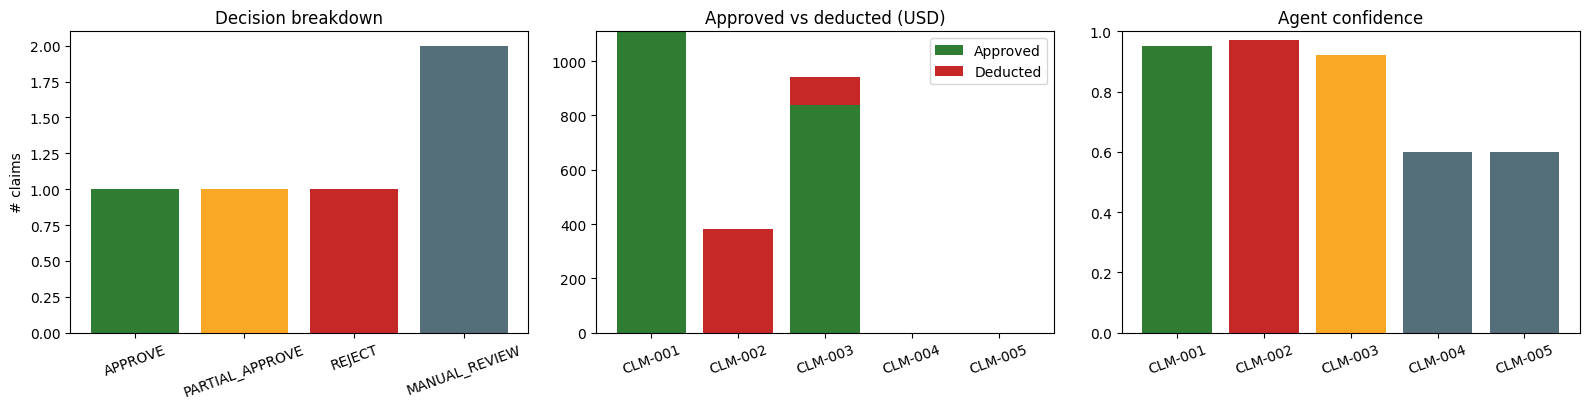

,claim_id,decision,total_claimed,approved_amount,deducted_amount,confidence
0,CLM-001,APPROVE,1110.0,1110.0,0.0,0.95
1,CLM-002,REJECT,380.0,0.0,380.0,0.97
2,CLM-003,PARTIAL_APPROVE,940.0,840.0,100.0,0.92
3,CLM-004,MANUAL_REVIEW,3000.0,0.0,0.0,0.6
4,CLM-005,MANUAL_REVIEW,220.0,0.0,0.0,0.6
TOTAL,—,—,5650.0,1950.0,480.0,—


In [20]:
import matplotlib
matplotlib.use("Agg", force=False)
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.DataFrame(RESULTS)
df["total_claimed"] = [sum(i["amount"] for i in c["items"]) for c in claims]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# 1) decision breakdown
order = ["APPROVE", "PARTIAL_APPROVE", "REJECT", "MANUAL_REVIEW"]
palette = {"APPROVE": "#2e7d32", "PARTIAL_APPROVE": "#f9a825",
           "REJECT": "#c62828", "MANUAL_REVIEW": "#546e7a"}
counts = df["decision"].value_counts().reindex(order, fill_value=0)
axes[0].bar(counts.index, counts.values, color=[palette[d] for d in counts.index])
axes[0].set_title("Decision breakdown")
axes[0].set_ylabel("# claims")
axes[0].tick_params(axis="x", rotation=20)

# 2) approved vs deducted per claim
x = range(len(df))
axes[1].bar(x, df["approved_amount"], label="Approved", color="#2e7d32")
axes[1].bar(x, df["deducted_amount"], bottom=df["approved_amount"],
            label="Deducted", color="#c62828")
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(df["claim_id"], rotation=20)
axes[1].set_title("Approved vs deducted (USD)")
axes[1].legend()

# 3) confidence per claim
axes[2].bar(df["claim_id"], df["confidence"],
            color=[palette[d] for d in df["decision"]])
axes[2].set_ylim(0, 1)
axes[2].set_title("Agent confidence")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("UI SS_1.png", dpi=150, bbox_inches="tight")   # saved next to the notebook
plt.show()

summary = df[["claim_id", "decision", "total_claimed", "approved_amount",
              "deducted_amount", "confidence"]].copy()
summary.loc["TOTAL"] = ["—", "—", summary["total_claimed"].sum(),
                        summary["approved_amount"].sum(),
                        summary["deducted_amount"].sum(), "—"]
summary

### Interactive claim inspector (optional UI)

If `ipywidgets` is installed, a dropdown lets a reviewer inspect any claim's full decision and
tool trace; otherwise a static per-claim printout is shown so the notebook still runs anywhere.

In [21]:
def render_claim(cid: str):
    r = next(x for x in RESULTS if x["claim_id"] == cid)
    print(json.dumps(r, indent=2))

try:
    import ipywidgets as widgets
    from IPython.display import display
    dd = widgets.Dropdown(options=[c["claim_id"] for c in claims], description="Claim:")
    out = widgets.Output()
    def _on_change(change):
        if change["name"] == "value":
            out.clear_output()
            with out: render_claim(change["new"])
    dd.observe(_on_change, names="value")
    display(dd, out)
    with out: render_claim(dd.value)
except ImportError:
    for c in claims:
        print("#" * 60); render_claim(c["claim_id"])

############################################################
{
  "claim_id": "CLM-001",
  "decision": "APPROVE",
  "approved_amount": 1110.0,
  "deducted_amount": 0.0,
  "missing_docs": [],
  "policy_refs": [
    "POL-APR-02",
    "POL-CAT-01"
  ],
  "confidence": 0.95,
  "explanation": "All items eligible (POL-CAT-01), receipts attached, within per-diem limits, submitted on time. Total $1110.00 falls in the manager tier (POL-APR-02).",
  "tools_used": [
    "check_timeliness",
    "check_ineligible_items",
    "check_airfare_class",
    "check_receipts",
    "check_per_diem_limits",
    "check_approval_threshold",
    "policy_lookup"
  ]
}
############################################################
{
  "claim_id": "CLM-002",
  "decision": "REJECT",
  "approved_amount": 0.0,
  "deducted_amount": 380.0,
  "missing_docs": [],
  "policy_refs": [
    "POL-CAT-02"
  ],
  "confidence": 0.97,
  "explanation": "All claimed items are ineligible under POL-CAT-02 (spa, minibar); nothing is reimb

## Design Notes & Reasoning

### Assumptions
- **Units drive per-diem math.** Each line item carries `units` (nights/days) parsed from the
  claim descriptions (e.g. "2 nights @ $180" → `units=2`), so caps are `cap × units`.
- **Trip dates are inclusive**; CLM-001's "3 days of meals" over 2026-06-10→12 is accepted as 3
  meal-days.
- **Timeliness** is measured from `trip_end` to `submitted` (≤ 30 days, POL-TIME-01).
- **Manual Review zeroes the amounts.** For `MANUAL_REVIEW` we report `approved_amount = 0` and
  put the *provisional* reimbursable figure in the explanation — a human, not the agent, decides.
- Receipts marked `attached: Yes` are assumed itemized and valid (no OCR / fraud checks in scope).

### Why certain cases route to Manual Review
| Trigger | Rule | Rationale |
|---|---|---|
| Missing required receipt (CLM-004 lodging, CLM-005 dinner) | POL-RCT-01/02 | Policy explicitly says don't silently reject — the reviewer can request the document. |
| Business-class airfare (CLM-004) | POL-AIR-01 | A pre-approval may exist, so auto-deducting would wrongly penalize the employee. |
| Total > $2,000 (CLM-004) | POL-APR-03 | Above the agent's authority; director approval required even if compliant. |
| Late submission | POL-TIME-01 | Lateness may have a legitimate cause the agent can't verify. |

The general principle: **the agent only auto-decides what it can fully verify from the data it
has**. Anything requiring information outside the claim (pre-approvals, absent documents,
organizational authority) goes to a human.

### Trade-offs
- **Keyword retrieval instead of embeddings.** With 12 short rules, keyword scoring is
  transparent, dependency-free, and sufficient; a vector DB would be over-engineering here.
- **Deterministic tools + LLM orchestration** rather than "LLM does the math": slightly more
  code, but decisions are reproducible and every dollar is traceable to a rule id.
- **Fallback engine** doubles as the validator's repair path — one code path guarantees the
  final cell always emits valid JSON.

### What I would improve next
1. Receipt OCR + line-item extraction to verify claimed amounts against actual receipts.
2. Duplicate-claim detection across the claim history (hash on employee+date+amount+vendor).
3. An evaluation harness with golden decisions to regression-test prompt/policy changes.
4. Currency handling and country-specific per-diem tables.
5. MCP-based tool exposure so the same tools serve other agents/hosts.

### Known gaps / limitations
- Only the 5 provided claims are supported end-to-end (per the brief — no invented claim set).
- `units` are trusted from intake; a malformed claim could mis-scale a cap (validation exists
  for output, not yet for intake).
- Confidence is heuristic in deterministic mode and self-reported in LLM mode — not calibrated.


## 8. Final structured results (required output — last code cell)

One JSON object per provided claim with **exactly** the required fields, schema-validated.

In [22]:
# validate every result once more, then emit the final JSON array
for r in RESULTS:
    v = tool_validate_output(r)
    assert v["valid"], f"{r['claim_id']}: {v['errors']}"

FINAL_JSON = json.dumps(RESULTS, indent=2)
print(FINAL_JSON)

[
  {
    "claim_id": "CLM-001",
    "decision": "APPROVE",
    "approved_amount": 1110.0,
    "deducted_amount": 0.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-APR-02",
      "POL-CAT-01"
    ],
    "confidence": 0.95,
    "explanation": "All items eligible (POL-CAT-01), receipts attached, within per-diem limits, submitted on time. Total $1110.00 falls in the manager tier (POL-APR-02).",
    "tools_used": [
      "check_timeliness",
      "check_ineligible_items",
      "check_airfare_class",
      "check_receipts",
      "check_per_diem_limits",
      "check_approval_threshold",
      "policy_lookup"
    ]
  },
  {
    "claim_id": "CLM-002",
    "decision": "REJECT",
    "approved_amount": 0.0,
    "deducted_amount": 380.0,
    "missing_docs": [],
    "policy_refs": [
      "POL-CAT-02"
    ],
    "confidence": 0.97,
    "explanation": "All claimed items are ineligible under POL-CAT-02 (spa, minibar); nothing is reimbursable.",
    "tools_used": [
      "check_timelines